# Ejercicio 1 Analisis de datos con pandas

### Cargar y explorar un dataframe

In [153]:
## importaciones
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

In [154]:


df = pd.read_csv("/home/jdvalmart/MachineDeepLearning/nivel_intermedio/viviendas_palmira.csv")

print(df.head())



          barrio  area_m2  habitaciones  banos  parqueaderos  estrato  \
0         Centro       80             3      2             1        3   
1   Las Mercedes       95             3      2             1        4   
2  Villa Fontana       70             2      2             1        3   
3      El Recreo      120             4      3             2        5   
4      San Pedro       60             2      1             0        2   

   precio_millones  
0              210  
1              260  
2              180  
3              420  
4              120  


explorar el dataframe

In [155]:
# primeras filas
df.head()

# información del dataset
df.info()

# estadísticas
df.describe()

# tamaño del DataFrame
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   barrio           20 non-null     object
 1   area_m2          20 non-null     int64 
 2   habitaciones     20 non-null     int64 
 3   banos            20 non-null     int64 
 4   parqueaderos     20 non-null     int64 
 5   estrato          20 non-null     int64 
 6   precio_millones  20 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.2+ KB


(20, 7)

### Manipulación de datos
seleccionar una sola columna

In [156]:
df["precio_millones"]

0     210
1     260
2     180
3     420
4     120
5     300
6     220
7     450
8     200
9     430
10    150
11    240
12    280
13    520
14    110
15    290
16    410
17    230
18    270
19    130
Name: precio_millones, dtype: int64

Sleccionar mas de una columna

In [157]:
df[["barrio", "precio_millones"]]

,barrio,precio_millones
0,Centro,210
1,Las Mercedes,260
2,Villa Fontana,180
3,El Recreo,420
4,San Pedro,120
5,Palmaseca,300
6,Santa Ana,220
7,El Bosque,450
8,Urbanización La Italia,200
9,Altamira,430


Ordenar por precio

In [158]:
df.sort_values(by="precio_millones", ascending=False)

,barrio,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones
13,Versalles,150,4,3,2,6,520
7,El Bosque,140,4,3,2,5,450
9,Altamira,130,4,3,2,5,430
3,El Recreo,120,4,3,2,5,420
16,Rincon del Bosque,125,4,3,2,5,410
5,Palmaseca,110,3,2,1,4,300
15,Santa Bárbara,105,3,2,1,4,290
12,Villa Claudia,100,3,2,2,4,280
18,Las Delicias,95,3,2,1,4,270
1,Las Mercedes,95,3,2,1,4,260


filtrar datos con precio mayor a 200 millones

In [159]:
df[df["precio_millones"] > 200]

,barrio,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones
0,Centro,80,3,2,1,3,210
1,Las Mercedes,95,3,2,1,4,260
3,El Recreo,120,4,3,2,5,420
5,Palmaseca,110,3,2,1,4,300
6,Santa Ana,85,3,2,1,3,220
7,El Bosque,140,4,3,2,5,450
9,Altamira,130,4,3,2,5,430
11,La Emilia,90,3,2,1,3,240
12,Villa Claudia,100,3,2,2,4,280
13,Versalles,150,4,3,2,6,520


Promedio de precio por estrato

In [160]:
df.groupby("estrato")["precio_millones"].mean()

estrato
2    127.500000
3    213.333333
4    280.000000
5    427.500000
6    520.000000
Name: precio_millones, dtype: float64

## Reto 

 crear una nueva columna

In [161]:
df["precio_m2"] = df["precio_millones"] / df["area_m2"]
print("Columna precio por m2 creada con exito")


Columna precio por m2 creada con exito


Filtrar por tramaño de casas

In [162]:
df[df["area_m2"] > 90]

,barrio,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2
1,Las Mercedes,95,3,2,1,4,260,2.736842
3,El Recreo,120,4,3,2,5,420,3.500000
5,Palmaseca,110,3,2,1,4,300,2.727273
7,El Bosque,140,4,3,2,5,450,3.214286
9,Altamira,130,4,3,2,5,430,3.307692
12,Villa Claudia,100,3,2,2,4,280,2.800000
13,Versalles,150,4,3,2,6,520,3.466667
15,Santa Bárbara,105,3,2,1,4,290,2.761905
16,Rincon del Bosque,125,4,3,2,5,410,3.280000
18,Las Delicias,95,3,2,1,4,270,2.842105


Filtrar por estratos mas altos

In [163]:
df[(df["estrato"] >= 4) & (df["precio_millones"] > 250)]

,barrio,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2
1,Las Mercedes,95,3,2,1,4,260,2.736842
3,El Recreo,120,4,3,2,5,420,3.500000
5,Palmaseca,110,3,2,1,4,300,2.727273
7,El Bosque,140,4,3,2,5,450,3.214286
9,Altamira,130,4,3,2,5,430,3.307692
12,Villa Claudia,100,3,2,2,4,280,2.800000
13,Versalles,150,4,3,2,6,520,3.466667
15,Santa Bárbara,105,3,2,1,4,290,2.761905
16,Rincon del Bosque,125,4,3,2,5,410,3.280000
18,Las Delicias,95,3,2,1,4,270,2.842105


# ejercicio 2 Estadisticas descriptivas y visualización bsica

estadisticas descriptivas

In [164]:
df.describe()

,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2
count,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000
mean,94.500000,3.000000,2.050000,1.15000,3.600000,271.000000,2.755206
std,27.810449,0.725476,0.686333,0.67082,1.187656,118.716824,0.438837
min,55.000000,2.000000,1.000000,0.00000,2.000000,110.000000,2.000000
25%,73.750000,2.750000,2.000000,1.00000,3.000000,195.000000,2.584034
50%,92.500000,3.000000,2.000000,1.00000,3.500000,250.000000,2.732057
75%,112.500000,3.250000,2.250000,2.00000,4.250000,327.500000,2.959821
max,150.000000,4.000000,3.000000,2.00000,6.000000,520.000000,3.500000


### distribución de precios

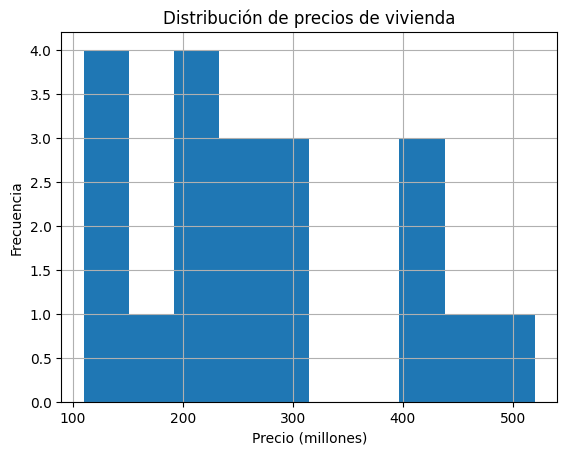

In [165]:
df["precio_millones"].hist(bins=10)

plt.title("Distribución de precios de vivienda")
plt.xlabel("Precio (millones)")
plt.ylabel("Frecuencia")
plt.show()

Precio promedio

In [166]:
df["precio_millones"].mean()
df["precio_millones"].max()
df["precio_millones"].min()
df["area_m2"].mean()
df.groupby("estrato")["precio_millones"].mean()
df.corr(numeric_only=True)

,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2
area_m2,1.000000,0.926069,0.911329,0.864694,0.973619,0.989323,0.917110
habitaciones,0.926069,1.000000,0.951330,0.865181,0.916271,0.941091,0.946092
banos,0.911329,0.951330,1.000000,0.897377,0.929787,0.935983,0.967935
parqueaderos,0.864694,0.865181,0.897377,1.000000,0.872014,0.883607,0.918317
estrato,0.973619,0.916271,0.929787,0.872014,1.000000,0.977267,0.942711
precio_millones,0.989323,0.941091,0.935983,0.883607,0.977267,1.000000,0.950640
precio_m2,0.917110,0.946092,0.967935,0.918317,0.942711,0.950640,1.000000


## Reto
Generar informe basico 

In [167]:
print("REPORTE BÁSICO DE EDA")
print("---------------------")

print("Número de viviendas:", len(df))
print("Precio promedio:", df["precio_millones"].mean())
print("Área promedio:", df["area_m2"].mean())

print("\nPrecio máximo:", df["precio_millones"].max())
print("Precio mínimo:", df["precio_millones"].min())

print("\nPromedio de precio por estrato:")
print(df.groupby("estrato")["precio_millones"].mean())

REPORTE BÁSICO DE EDA
---------------------
Número de viviendas: 20
Precio promedio: 271.0
Área promedio: 94.5

Precio máximo: 520
Precio mínimo: 110

Promedio de precio por estrato:
estrato
2    127.500000
3    213.333333
4    280.000000
5    427.500000
6    520.000000
Name: precio_millones, dtype: float64


# Ejercicio 3 Limpieza de datos


identificar problemas con los datos


In [168]:
df.isnull() # detetar nulos
df.isnull().sum() # contar nulos
df.duplicated() # detetar duplicados
df.duplicated().sum()  # contar duplicados

df[df["precio_millones"] < 0] #detetar  valores erroneos


,barrio,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2


Limpieza de datos

In [169]:
df = df.dropna() # eliminar nulos
df = df[df["precio_millones"] > 0] # eliminar precios negativos
df = df.drop_duplicates() # eliminar duplicados
df[df.duplicated()] #ver duplicados



,barrio,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2


In [170]:
df.duplicated().sum() # verificar duplicados

np.int64(0)

# Ejercicio 4 Tranformación de datos

Normalizar variables numericas

In [171]:
df["area_normalizada"] = df["area_m2"] / df["area_m2"].max()

transformar variables categoricas

In [172]:
df_encoded = pd.get_dummies(df, columns=["barrio"])

df_encoded.head()

,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2,area_normalizada,barrio_Altamira,barrio_Centro,...,barrio_Portal de las Palmas,barrio_Rincon del Bosque,barrio_San Pedro,barrio_Santa Ana,barrio_Santa Bárbara,barrio_Urbanización La Italia,barrio_Versalles,barrio_Villa Claudia,barrio_Villa Fontana,barrio_Zamorano
0,80,3,2,1,3,210,2.625000,0.533333,False,True,...,False,False,False,False,False,False,False,False,False,False
1,95,3,2,1,4,260,2.736842,0.633333,False,False,...,False,False,False,False,False,False,False,False,False,False
2,70,2,2,1,3,180,2.571429,0.466667,False,False,...,False,False,False,False,False,False,False,False,True,False
3,120,4,3,2,5,420,3.500000,0.800000,False,False,...,False,False,False,False,False,False,False,False,False,False
4,60,2,1,0,2,120,2.000000,0.400000,False,False,...,False,False,True,False,False,False,False,False,False,False


In [179]:
df["habitaciones_por_m2"] = df["habitaciones"] / df["area_m2"] # relación habitaciones por metro cuadrado
df["precio_por_m2"] = df["precio_millones"] / df["area_m2"] # precio por m2
df["banos_por_habitacion"] = df["banos"] / df["habitaciones"] # densidad de baños

## Reto crear una nueva carateristica que mejore la predicción del precio

In [174]:
df["indice_lujo"] = (
    df["habitaciones"] +
    df["banos"] +
    df["parqueaderos"] +
    df["estrato"]
)

df.head()

,barrio,area_m2,habitaciones,banos,parqueaderos,estrato,precio_millones,precio_m2,area_normalizada,habitaciones_por_m2,precio_por_m2,banos_por_habitacion,indice_lujo
0,Centro,80,3,2,1,3,210,2.625000,0.533333,0.037500,2.625000,0.666667,9
1,Las Mercedes,95,3,2,1,4,260,2.736842,0.633333,0.031579,2.736842,0.666667,10
2,Villa Fontana,70,2,2,1,3,180,2.571429,0.466667,0.028571,2.571429,1.000000,8
3,El Recreo,120,4,3,2,5,420,3.500000,0.800000,0.033333,3.500000,0.750000,14
4,San Pedro,60,2,1,0,2,120,2.000000,0.400000,0.033333,2.000000,0.500000,5


# Ejercicio 5 validación cruzada

separar variables

In [175]:
X = df[["area_m2","habitaciones","banos","estrato"]]
y = df["precio_millones"]

crear el modelo

In [176]:
modelo = LinearRegression()

aplicar validación cruzada

In [177]:

scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print(scores)

[-296.00664272 -364.19687579 -209.59034502 -315.15868444 -144.92503465]


metrica final

In [178]:
import numpy as np

rmse = np.sqrt(-scores)

print("RMSE por fold:", rmse)
print("RMSE promedio:", rmse.mean())

RMSE por fold: [17.20484358 19.08394288 14.47723541 17.75270921 12.03848141]
RMSE promedio: 16.111442498519928
